## Google Colab 한글 폰트 설치

In [4]:
import sys

# Google Colab 환경에서 실행 중인지 확인
if 'google.colab' in sys.modules:
    # debconf를 Noninteractive 모드로 설정
    !echo 'debconf debconf/frontend select Noninteractive' | \
    debconf-set-selections
    # fonts-nanum 패키지를 설치
    !sudo apt-get -qq -y install fonts-nanum

    # Matplotlib의 폰트 매니저 가져오기
    import matplotlib.font_manager as fm

    # 나눔 폰트의 시스템 경로 찾기
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])

    # 찾은 각 나눔 폰트를 Matplotlib 폰트 매니저에 추가
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

In [5]:
# 필요한 패키지
import numpy as np
import matplotlib.pyplot as plt

import scipy
from scipy import linalg as la
import scipy.stats as ss
import scipy.special

# 한글출력
plt.rcParams['font.family'] = 'Malgun Gothic' #  Windows 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False

# 필요한 패키지 2
from pgmpy.factors.discrete import JointProbabilityDistribution as JPD
import sympy

scipy.__version__

'1.15.3'

- 테스트

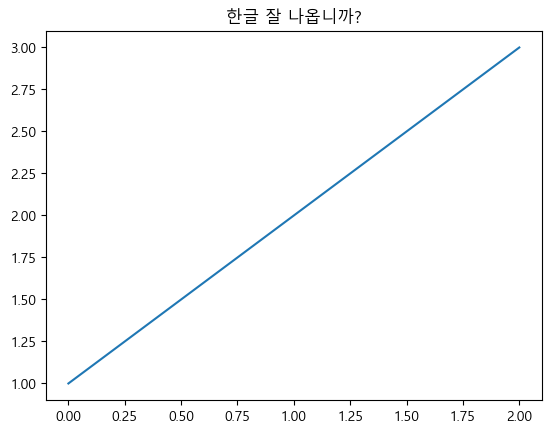

In [6]:
plt.plot([1, 2, 3])
plt.title("한글 잘 나옵니까?")
plt.show()

# 라이브러리 불러오기

In [7]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# 시계열 시각화 맛보기

## matplotlib 설정

## 데이터 불러오기

In [8]:
DATA_PATH = './data/'

df = pd.read_csv(DATA_PATH + 'widget_sales.csv')

df.head()

,widget_sales
0,50.496714
1,50.805493
2,51.477758
3,53.542228
4,54.873108


## 주어진 시계열 데이터 시각화

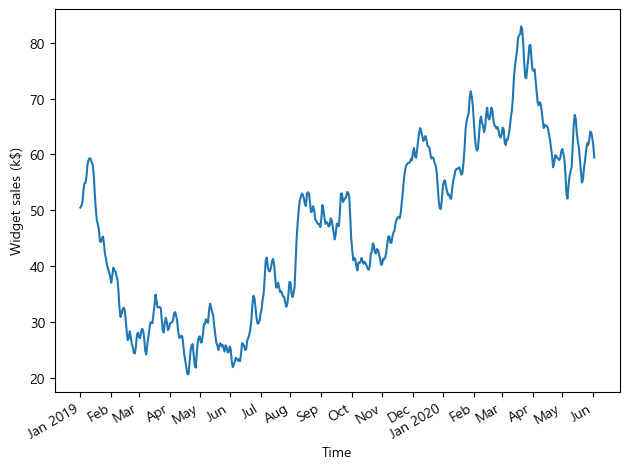

In [9]:
fig, ax = plt.subplots()

ax.plot(df['widget_sales'])
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales (k$)')

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498],
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 정상성 확인
- 가설검정
  + 귀무가설 : 시계열 데이터는 비정상 시계열이다. (정상성 시계열이 아니다.)
  + 대립가설 : 시계열 데이터는 정상성 시계열이다.
- 귀무가설 채택 (정상성 시계열이 아님)

In [10]:
ADF_result = adfuller(df['widget_sales'])

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -1.5121662069359045
p-value: 0.5274845352272606


## 차분 후, 시각화

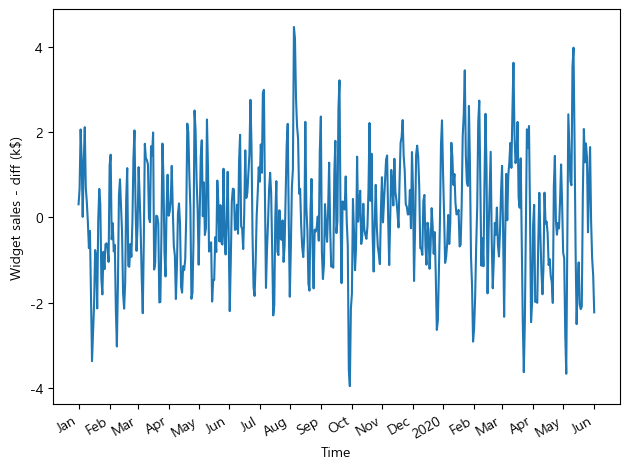

In [11]:
widget_sales_diff = np.diff(df['widget_sales'], n=1)

fig, ax = plt.subplots()

ax.plot(widget_sales_diff)
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales - diff (k$)')

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498],
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 차분 데이터 정상성 확인
- 귀무가설 기각 ==> 대립가설 채택 (정상성 시계열로 바뀜)

In [12]:
ADF_result = adfuller(widget_sales_diff)

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}') 

ADF Statistic: -10.576657780341959
p-value: 7.076922818587193e-19


## 자기상관관계 그래프
- ACF 도식화 결과 지연 2까지는 유의한 계수가 있음 확인
- 2차 이동평균 모델 또는 MA(2) 모델 사용하여 정상적 시계열 예측

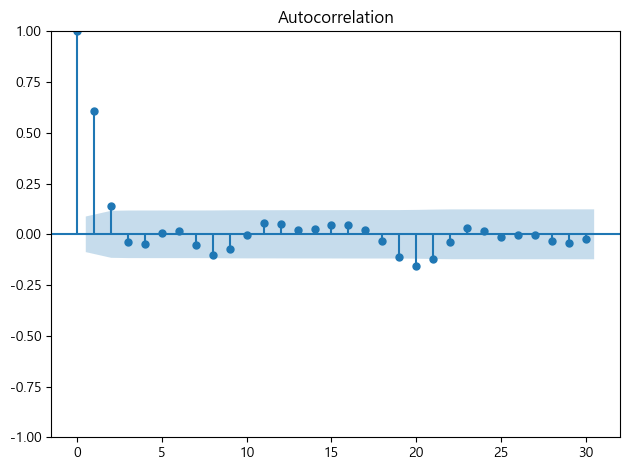

In [13]:
plot_acf(widget_sales_diff, lags=30);

plt.tight_layout()
plt.show()

# 이동평균 예측
- MA(2) 모델 개발

## 데이터 분리
- 시계열 데이터 분리를 할 때는 항상 구간으로 설정
- 머신러닝/딥러닝 데이터 분리를 할 때 층화추출로 설정

In [14]:
df_diff = pd.DataFrame({'widget_sales_diff': widget_sales_diff})

train = df_diff[:int(0.9*len(df_diff))]
test = df_diff[int(0.9*len(df_diff)):]

print(len(train))
print(len(test))

449
50


## 데이터 시각화

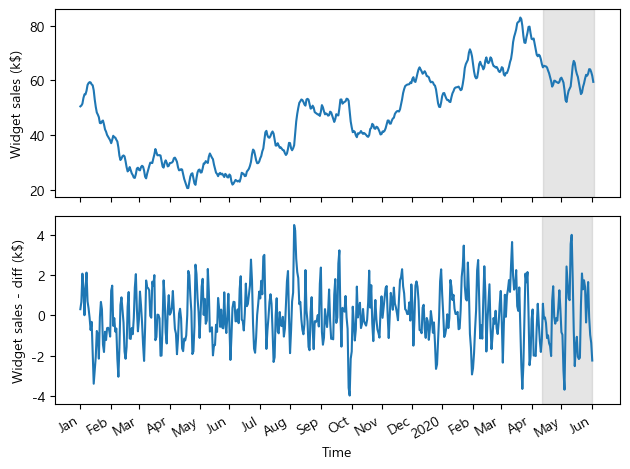

In [15]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True)

ax1.plot(df['widget_sales'])
ax1.set_xlabel('Time')
ax1.set_ylabel('Widget sales (k$)')
ax1.axvspan(450, 500, color='#808080', alpha=0.2)

ax2.plot(df_diff['widget_sales_diff'])
ax2.set_xlabel('Time')
ax2.set_ylabel('Widget sales - diff (k$)')
ax2.axvspan(449, 498, color='#808080', alpha=0.2)

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498],
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 롤링 예측 함수 구현
- train_len : 데이터 요소의 개수 초기화
- horizon : 테스트 집합의 길이와 같으며, 예측할 값의 개수
- window : 한 번에 예측할 시간 단계 횟수 지정
- method : 사용할 모델 지정

In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    """
    롤링 윈도우 방법으로 시계열 데이터를 예측하는 함수.

    매개변수:
    - df (pd.DataFrame): 입력 시계열 데이터.
    - train_len (int): 학습 데이터의 길이 (초기 학습 구간 크기).
    - horizon (int): 예측할 데이터의 기간 (총 예측 기간).
    - window (int): 롤링 윈도우 크기.
    - method (str): 예측 방법 ('mean', 'last', 'MA' 중 하나 선택).

    반환값:
    - list: 예측된 값의 리스트.
    """

    # 학습 기간과 예측 기간을 합친 전체 길이
    total_len = train_len + horizon

    # 'mean' 방법: 이전 데이터의 평균값을 예측 값으로 사용
    if method == 'mean':
        pred_mean = []

        for i in range(train_len, total_len, window):  # 윈도우 단위로 반복
            # 현재 윈도우 이전까지의 평균 계산
            mean = np.mean(df[:i].values)
            # 계산된 평균값을 현재 윈도우 크기만큼 예측값 리스트에 추가
            pred_mean.extend(mean for _ in range(window))

        return pred_mean

    # 'last' 방법: 이전 데이터의 마지막 값을 예측 값으로 사용
    elif method == 'last':
        pred_last_value = []

        for i in range(train_len, total_len, window):  # 윈도우 단위로 반복
            # 현재 윈도우 이전까지의 마지막 값 가져오기
            last_value = df[:i].iloc[-1].values[0]
            # 가져온 마지막 값을 현재 윈도우 크기만큼 예측값 리스트에 추가
            pred_last_value.extend(last_value for _ in range(window))

        return pred_last_value

    # 'MA' 방법: 이동평균(MA) 모델을 사용해 예측
    elif method == 'MA':
        pred_MA = []

        for i in range(train_len, total_len, window):  # 윈도우 단위로 반복
            # SARIMAX 모델 설정: (p,d,q), p는 AR모형, d는 차분, q는 MA모형
            # SARIMAX 모델 설정: (0,0,2)은 MA(2) 모델을 의미
            model = SARIMAX(df[:i], order=(0, 0, 2))
            # SARIMAX 모델 학습
            res = model.fit(disp=False)
            # 학습된 모델로 예측 수행
            predictions = res.get_prediction(0, i + window - 1)
            # 예측값 중 마지막 윈도우에 해당하는 값들 가져오기
            oos_pred = predictions.predicted_mean.iloc[-window:]
            # 예측값을 결과 리스트에 추가
            pred_MA.extend(oos_pred)

        return pred_MA


In [17]:
pred_df = test.copy()

TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2

pred_mean = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_value = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_MA = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'MA')

pred_df['pred_mean'] = pred_mean
pred_df['pred_last_value'] = pred_last_value
pred_df['pred_MA'] = pred_MA

pred_df.head()

,widget_sales_diff,pred_mean,pred_last_value,pred_MA
449,-1.170131,0.034319,-1.803658,-1.078833
450,0.580967,0.034319,-1.803658,-0.273309
451,-0.144902,0.032861,0.580967,0.781223
452,-0.096564,0.032861,0.580967,0.234969
453,-0.372334,0.032183,-0.096564,0.168994


## 훈련 데이터 도식화
- 훈련 집합과 테스트 집합 간의 변화 확인

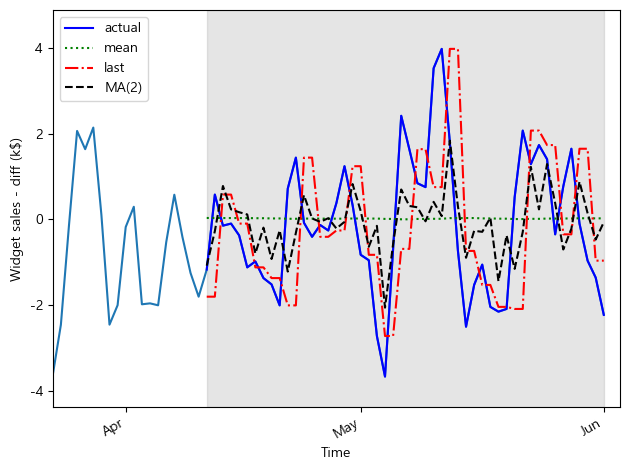

In [18]:
fig, ax = plt.subplots()

ax.plot(df_diff['widget_sales_diff'])
ax.plot(pred_df['widget_sales_diff'], 'b-', label='actual')
ax.plot(pred_df['pred_mean'], 'g:', label='mean')
ax.plot(pred_df['pred_last_value'], 'r-.', label='last')
ax.plot(pred_df['pred_MA'], 'k--', label='MA(2)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Widget sales - diff (k$)')

ax.axvspan(449, 498, color='#808080', alpha=0.2)

ax.set_xlim(430, 500)

plt.xticks(
    [439, 468, 498],
    ['Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

### MSE
- 수치 예측 관련 평가지표는 값이 낮으면 낮을수록 좋은 모델

In [19]:
from sklearn.metrics import mean_squared_error

mse_mean = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_mean'])
mse_last = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_last_value'])
mse_MA = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_MA'])

print(mse_mean, mse_last, mse_MA)

2.5606299456880537 3.2494260812249225 1.9481714497514804


## 모형 평가

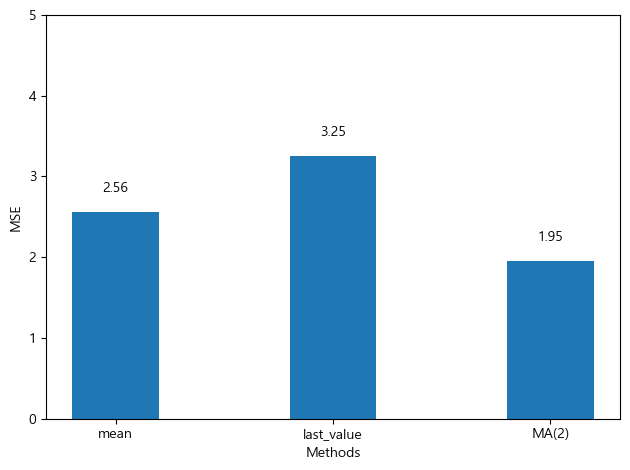

In [20]:
fig, ax = plt.subplots()

x = ['mean', 'last_value', 'MA(2)']
y = [mse_mean, mse_last, mse_MA]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Methods')
ax.set_ylabel('MSE')
ax.set_ylim(0, 5)

for index, value in enumerate(y):
    plt.text(x=index, y=value+0.25, s=str(round(value, 2)), ha='center')

plt.tight_layout()
plt.show()

## 예측결과 역변환
- 정상적 수열에 대한 모델 확보
- 예측결과를 역변환하여 데이터 집합의 변환하지 않은 원래 규모로 되돌려야 함

In [21]:
df['pred_widget_sales'] = pd.Series()
df['pred_widget_sales'][450:] = df['widget_sales'].iloc[450] + pred_df['pred_MA'].cumsum()

## 역변환한 MA(2) 결과 시각화
- 가장 큰 최저점과 가장 낮은 최고점은 예측하지 못함

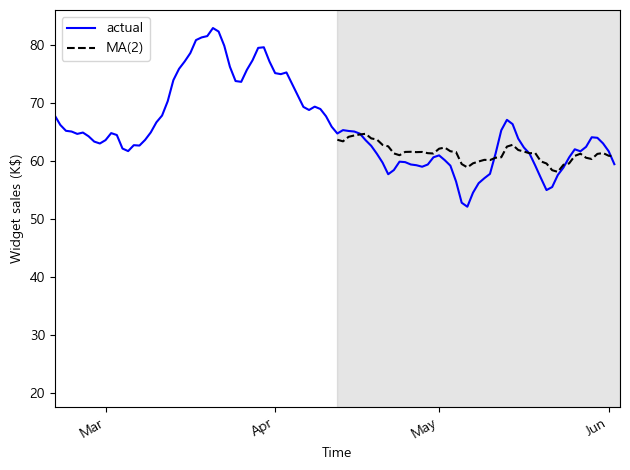

In [22]:
fig, ax = plt.subplots()

ax.plot(df['widget_sales'], 'b-', label='actual')
ax.plot(df['pred_widget_sales'], 'k--', label='MA(2)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Widget sales (K$)')

ax.axvspan(450, 500, color='#808080', alpha=0.2)

ax.set_xlim(400, 500)

plt.xticks(
    [409, 439, 468, 498],
    ['Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

In [23]:
from sklearn.metrics import mean_absolute_error

mae_MA_undiff = mean_absolute_error(df['widget_sales'].iloc[450:], df['pred_widget_sales'].iloc[450:])

print(mae_MA_undiff)

2.3244709244291437


# 자기회귀과정

## 라이브러리 불러오기

In [24]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

## 데이터 시각화
- 소매점의 주간 평균 유동인구 예측

In [25]:
DATA_PATH = './data/'

df = pd.read_csv(DATA_PATH + 'foot_traffic.csv')

df.head()

,foot_traffic
0,500.496714
1,500.522366
2,501.426876
3,503.295990
4,504.132695


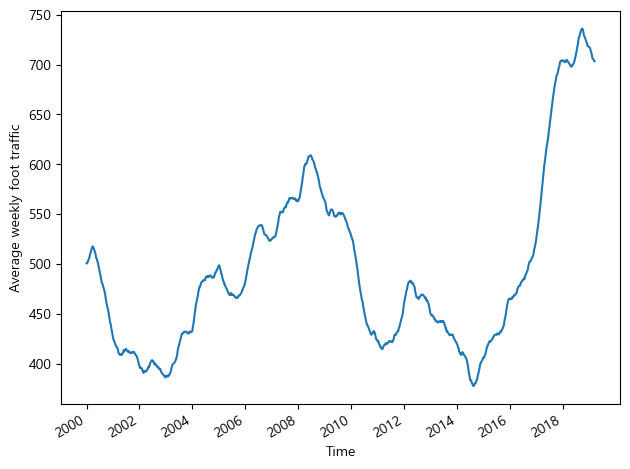

In [26]:
fig, ax = plt.subplots()

ax.plot(df['foot_traffic'])
ax.set_xlabel('Time')
ax.set_ylabel('Average weekly foot traffic')

plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

## 차분 및 정상성 확인
- 가설설정
  + 귀무가설 : 시계열 데이터는 비정상시계열이다. (정상시계열이 아니다.)
  + 대립가설 : 시계열 데이터는 비정상시계열이 아니다. (정상시계열이다.)

In [27]:
ADF_result = adfuller(df['foot_traffic'])

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -1.1758885999240727
p-value: 0.6838808917896197


ADF Statistic: -5.268231347422053
p-value: 6.369317654781036e-06


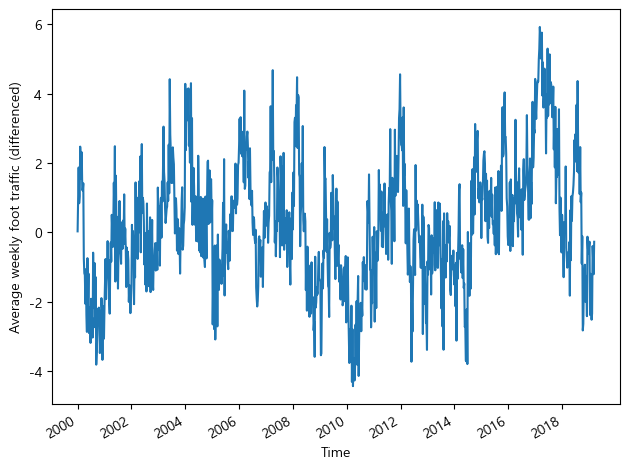

In [28]:
foot_traffic_diff = np.diff(df['foot_traffic'], n=1) #차분 진행

# 정상성 확인 ADF 검정
ADF_diff_result = adfuller(foot_traffic_diff)

print(f'ADF Statistic: {ADF_diff_result[0]}')
print(f'p-value: {ADF_diff_result[1]}')

# 시각화
# 정상 시계열의 특징1 : 평균이 일정하다.
# 정상 시계열의 특징2 : 분산이 일정하다.
fig, ax = plt.subplots()

ax.plot(foot_traffic_diff)
ax.set_xlabel('Time')
ax.set_ylabel('Average weekly foot traffic (differenced)')

plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

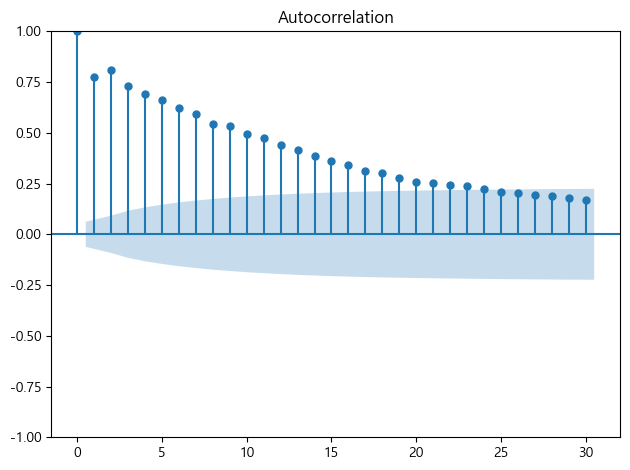

In [29]:
plot_acf(foot_traffic_diff, lags=30); # 자기상관그래프, 비유적으로 설명하면 한달전 기록이 오늘까지 영향을 줌

plt.tight_layout()
plt.show()

## 편자기상관함수 (PACF) - 가상 데이터
- 정상적 자기회귀과정의 차수 구하기
- ACF 도식으로는 차수에 대한 정보 얻을 수 없음
- PACF 함수 사용

In [30]:
from statsmodels.tsa.arima_process import ArmaProcess
import numpy as np

np.random.seed(42)

ma2 = np.array([1, 0, 0])
ar2 = np.array([1, -0.33, -0.50])

AR2_process = ArmaProcess(ar2, ma2).generate_sample(nsample=1000)

- 해석 : 차수 2인 자기회귀과정으로 기반
  + 지연 2 이후에는 편자기상관계수가 0에서 큰 차이가 없음

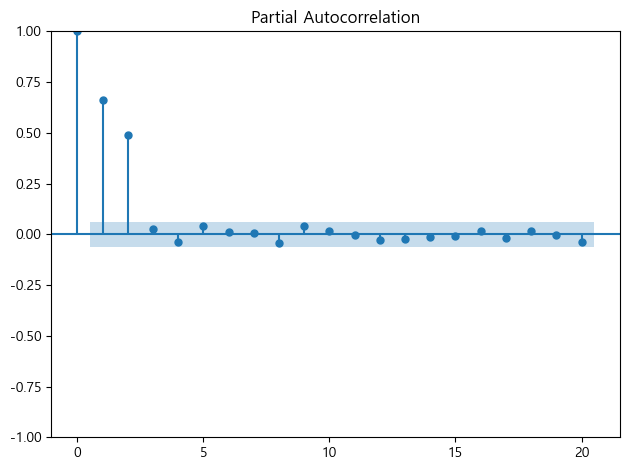

In [31]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(AR2_process, lags=20);
plt.tight_layout()
plt.show()

## 편자기상관함수 (PACF) - 실제데이터
- 지연 3 이후에는 유의한 계수가 없음 확인, AR(3) 모형
- 차분된 주간 평균 유동 인구는 자수 3의 자기회귀과정

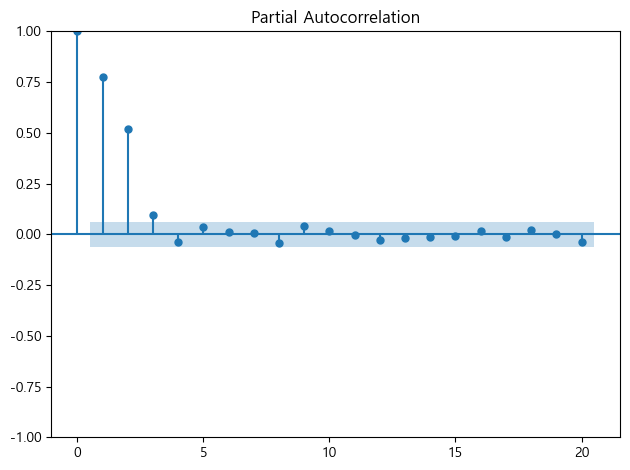

In [32]:
plot_pacf(foot_traffic_diff, lags=20);
plt.tight_layout()
plt.show()

## 자기회귀과정 예측
- 지난 52주간의 데이터, 테스트 집합에 저장
- 나머지는 훈련 집합에 저장

In [33]:
df_diff = pd.DataFrame({'foot_traffic_diff': foot_traffic_diff})

train = df_diff[:-52]
test = df_diff[-52:]

print(len(train))
print(len(test))

947
52


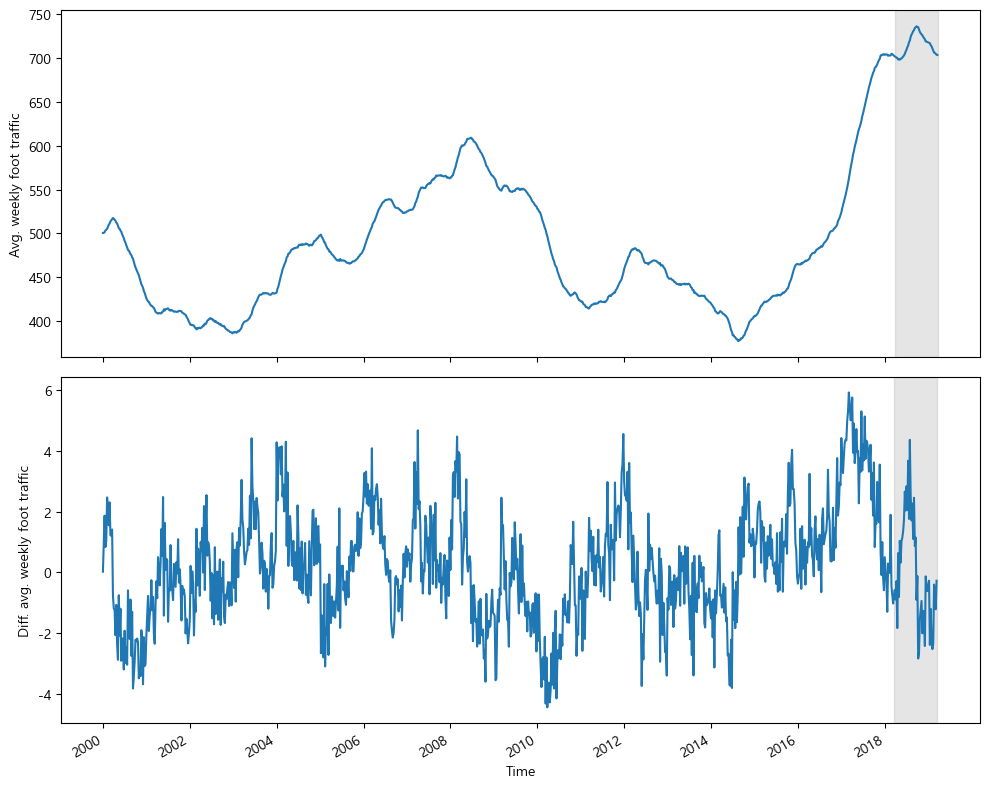

In [34]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(10, 8))

ax1.plot(df['foot_traffic'])
ax1.set_xlabel('Time')
ax1.set_ylabel('Avg. weekly foot traffic')
ax1.axvspan(948, 1000, color='#808080', alpha=0.2)

ax2.plot(df_diff['foot_traffic_diff'])
ax2.set_xlabel('Time')
ax2.set_ylabel('Diff. avg. weekly foot traffic')
ax2.axvspan(947, 999, color='#808080', alpha=0.2)

plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

### 세가지 기법 사용
- 과거 평균
- 마지막으로 측정된 값 베이스라인
- AR(3) 모델

In [35]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:

    total_len = train_len + horizon
    end_idx = train_len

    if method == 'mean':
        pred_mean = []

        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))

        return pred_mean

    elif method == 'last':
        pred_last_value = []

        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend(last_value for _ in range(window))

        return pred_last_value

    elif method == 'AR':
        pred_AR = []

        for i in range(train_len, total_len, window):
            # SARIMAX(p,d,q)
            model = SARIMAX(df[:i], order=(3,0,0))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_AR.extend(oos_pred)

        return pred_AR

In [36]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 1

pred_mean = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_value = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_AR = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'AR')

test['pred_mean'] = pred_mean
test['pred_last_value'] = pred_last_value
test['pred_AR'] = pred_AR

test.head()

,foot_traffic_diff,pred_mean,pred_last_value,pred_AR
947,-0.776601,0.213270,-1.021893,-0.719714
948,-0.574631,0.212226,-0.776601,-0.814547
949,-0.890697,0.211397,-0.574631,-0.664738
950,-0.283552,0.210237,-0.890697,-0.641469
951,-1.830685,0.209717,-0.283552,-0.579279


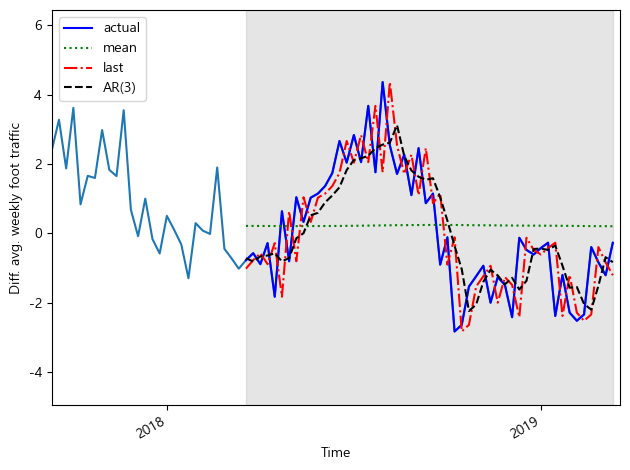

In [37]:
fig, ax = plt.subplots()

ax.plot(df_diff['foot_traffic_diff'])
ax.plot(test['foot_traffic_diff'], 'b-', label='actual')
ax.plot(test['pred_mean'], 'g:', label='mean')
ax.plot(test['pred_last_value'], 'r-.', label='last')
ax.plot(test['pred_AR'], 'k--', label='AR(3)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Diff. avg. weekly foot traffic')

ax.axvspan(947, 998, color='#808080', alpha=0.2)

ax.set_xlim(920, 999)

plt.xticks([936, 988],[2018, 2019])

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

## 모형 평가 비교

In [38]:
from sklearn.metrics import mean_squared_error

mse_mean = mean_squared_error(test['foot_traffic_diff'], test['pred_mean'])
mse_last = mean_squared_error(test['foot_traffic_diff'], test['pred_last_value'])
mse_AR = mean_squared_error(test['foot_traffic_diff'], test['pred_AR'])

print(mse_mean, mse_last, mse_AR)

3.1079979374701447 1.448730118495964 0.924247916855256


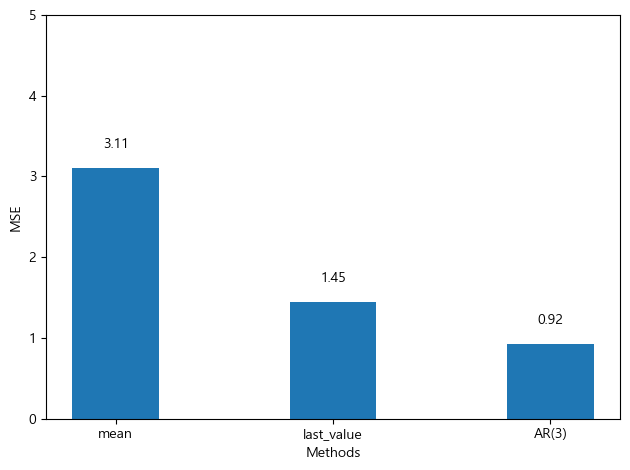

In [39]:
fig, ax = plt.subplots()

x = ['mean', 'last_value', 'AR(3)']
y = [mse_mean, mse_last, mse_AR]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Methods')
ax.set_ylabel('MSE')
ax.set_ylim(0, 5)

for index, value in enumerate(y):
    plt.text(x=index, y=value+0.25, s=str(round(value, 2)), ha='center')

plt.tight_layout()
plt.show()

## AR(3) 모델의 차분하지 않은 예측값

In [40]:
df['pred_foot_traffic'] = pd.Series()
df['pred_foot_traffic'][948:] = df['foot_traffic'].iloc[948] + test['pred_AR'].cumsum()

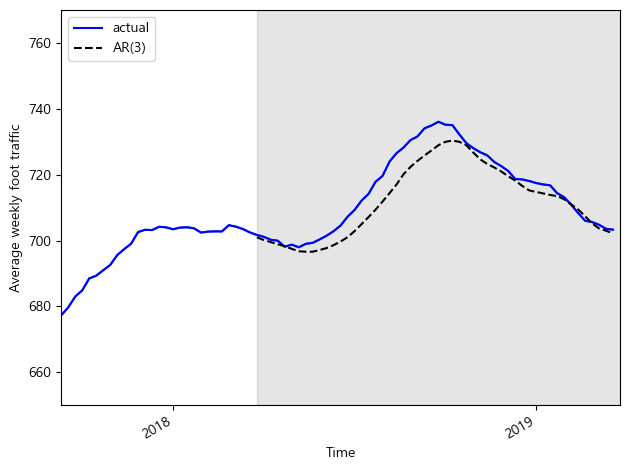

In [41]:
fig, ax = plt.subplots()

ax.plot(df['foot_traffic'])
ax.plot(df['foot_traffic'], 'b-', label='actual')
ax.plot(df['pred_foot_traffic'], 'k--', label='AR(3)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Average weekly foot traffic')

ax.axvspan(948, 1000, color='#808080', alpha=0.2)

ax.set_xlim(920, 1000)
ax.set_ylim(650, 770)

plt.xticks([936, 988],[2018, 2019])

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

- 해석 : 한 주의 유동인구에 대한 예측이 실제값보다 평균적으로 3.45명 정도 높거나 낮게 차이 보임

In [42]:
from sklearn.metrics import mean_absolute_error

mae_AR_undiff = mean_absolute_error(df['foot_traffic'][948:], df['pred_foot_traffic'][948:])

print(mae_AR_undiff)

3.478033556624955
